# Comprehensive Heart Disease Dataset

## Imports

In [ ]:
%reset -f
!pip install keras-tuner --upgrade
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
import sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.svm import SVC
import seaborn as sns
import shap
import tensorflow as tf
import keras
import keras_tuner
from tensorflow.keras import regularizers
from sklearn.metrics import precision_recall_curve
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.5 MB/s eta 0:00:00


## Data Handling

In [ ]:
df = pd.read_csv('heart_statlog_cleveland_hungary_final.csv', header=0)

In [ ]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [ ]:
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [ ]:
df[df['resting ecg'] == 0.0]

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
5,39,1,3,120,339,0,0,170,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1184,57,0,4,140,241,0,0,123,1,0.2,2,1
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1


In [ ]:
df[df['cholesterol'] == 0]

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
294,65,1,4,115,0,0,0,93,1,0.0,2,1
295,32,1,1,95,0,1,0,127,0,0.7,1,1
296,61,1,4,105,0,1,0,110,1,1.5,1,1
297,50,1,4,145,0,1,0,139,1,0.7,2,1
298,57,1,4,110,0,1,1,131,1,1.4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
515,43,1,4,122,0,0,0,120,0,0.5,1,1
516,63,1,3,130,0,1,1,160,0,3.0,2,0
519,48,1,3,102,0,1,1,110,1,1.0,3,1
536,56,1,4,130,0,0,2,122,1,1.0,2,1


In [ ]:
df[df['resting bp s'] == 0]

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
450,55,1,3,0,0,0,0,155,0,1.5,2,1


In [ ]:
df.loc[df['cholesterol'] == 0, 'cholesterol'] = np.nan
df.loc[df['resting ecg'] == 0, 'resting ecg'] = np.nan
df.drop(450, inplace=True)

In [ ]:
df = df.drop_duplicates()

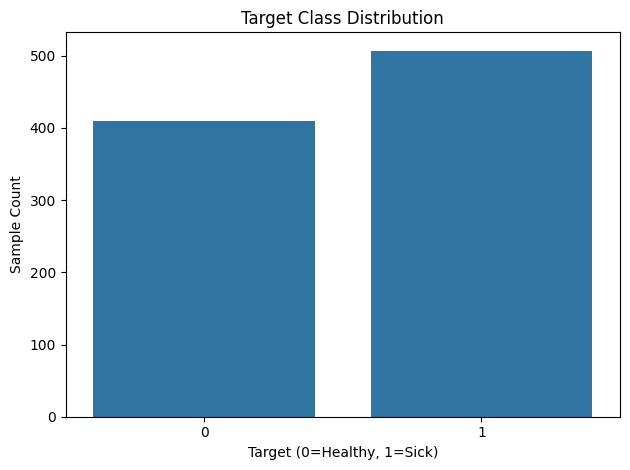

In [ ]:
sns.countplot(data=df, x='target')
plt.title("Target Class Distribution")
plt.xlabel("Target (0=Healthy, 1=Sick)")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

In [ ]:
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289.0,0,NaN,172,0,0.0,1,0
1,49,0,3,160,180.0,0,NaN,156,0,1.0,2,1
2,37,1,2,130,283.0,0,1.0,98,0,0.0,1,0
3,48,0,4,138,214.0,0,NaN,108,1,1.5,2,1
4,54,1,3,150,195.0,0,NaN,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264.0,0,NaN,132,0,1.2,2,1
1186,68,1,4,144,193.0,1,NaN,141,0,3.4,2,1
1187,57,1,4,130,131.0,0,NaN,115,1,1.2,2,1
1188,57,0,2,130,236.0,0,2.0,174,0,0.0,2,1


In [ ]:
X,Y = df.drop('target', axis=1), df['target']
Y
x_train, x_test, y_train, y_test = train_test_split(X,Y, random_state=10, test_size=0.25)

In [ ]:
scaled_features = ['age','resting bp s', 'max heart rate','oldpeak','cholesterol']
categorical_features = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina']
scaler = MinMaxScaler()
ct = ColumnTransformer([('scaler', scaler, scaled_features )])

In [ ]:
impute = IterativeImputer(random_state = 10)
impute.set_output(transform="pandas")
ct.set_output(transform="pandas")
x_train_impute = impute.fit_transform(x_train)
x_test_impute = impute.transform(x_test)
x_train_scaled = ct.fit_transform(x_train_impute)
x_test_scaled = ct.transform(x_test_impute)



In [ ]:
x_train_impute

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope
204,31.0,0.0,2.0,100.0,219.000000,0.0,1.000000,150.0,0.0,0.0,1.0
84,56.0,1.0,4.0,150.0,213.000000,1.0,1.418627,125.0,1.0,1.0,2.0
355,55.0,1.0,4.0,120.0,244.734977,0.0,1.000000,92.0,0.0,0.3,1.0
278,52.0,1.0,4.0,170.0,223.000000,0.0,1.386205,126.0,1.0,1.5,2.0
760,51.0,1.0,1.0,125.0,213.000000,0.0,2.000000,125.0,1.0,1.4,1.0
...,...,...,...,...,...,...,...,...,...,...,...
370,63.0,1.0,4.0,150.0,245.289825,0.0,1.252981,86.0,1.0,2.0,2.0
321,59.0,1.0,3.0,125.0,244.333567,1.0,1.753609,175.0,0.0,2.6,2.0
529,49.0,1.0,3.0,131.0,142.000000,0.0,1.385313,127.0,1.0,1.5,2.0
125,54.0,1.0,2.0,120.0,246.000000,0.0,1.377008,110.0,0.0,0.0,1.0


In [ ]:
print(y_train.isna().sum())

0


## SVM

In [ ]:
param_grid = {
    'model__C': [0.1,1,10],
    'model__kernel': ['poly','rbf'],
    'model__degree': [2,3,4],
    'model__gamma': ['scale','auto',0.1,0.01]

}

In [ ]:
svm_pipeline = Pipeline([('imputer', impute),('preprocessor', ct), ('model', SVC(C=1, gamma='scale', kernel='rbf', degree=2, class_weight='balanced',probability=True))])

In [ ]:
grid_search = GridSearchCV(estimator=svm_pipeline,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           verbose=3,
                           n_jobs=-1)

In [ ]:
#grid_search.fit(x_train,y_train)

In [ ]:
#print(grid_search.best_params_)

In [ ]:
svm_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', IterativeImputer(random_state=10)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('scaler', MinMaxScaler(),
                                                  ['age', 'resting bp s',
                                                   'max heart rate', 'oldpeak',
                                                   'cholesterol'])])),
                ('model',
                 SVC(C=1, class_weight='balanced', degree=2,
                     probability=True))])

In [ ]:
pred = svm_pipeline.predict(x_test)
cr = classification_report(y_test, pred)
print(cr)

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       105
           1       0.81      0.70      0.75       125

    accuracy                           0.75       230
   macro avg       0.75      0.75      0.75       230
weighted avg       0.76      0.75      0.75       230



Text(0.5, 1.0, 'SVM Confusion Matrix')

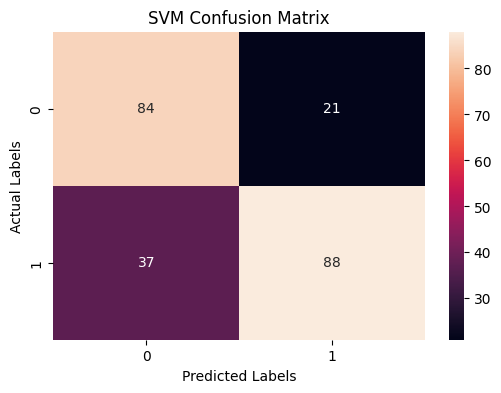

In [ ]:
plt.figure(figsize=(6, 4))
svm_cm = confusion_matrix(y_test, pred)


sns.heatmap(svm_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('SVM Confusion Matrix')

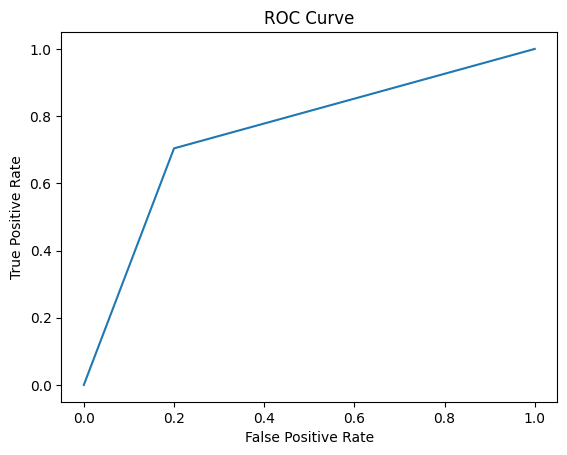

In [ ]:
svm_fpr, svm_tpr, threshold = roc_curve(y_test, pred)
plt.plot(svm_fpr, svm_tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

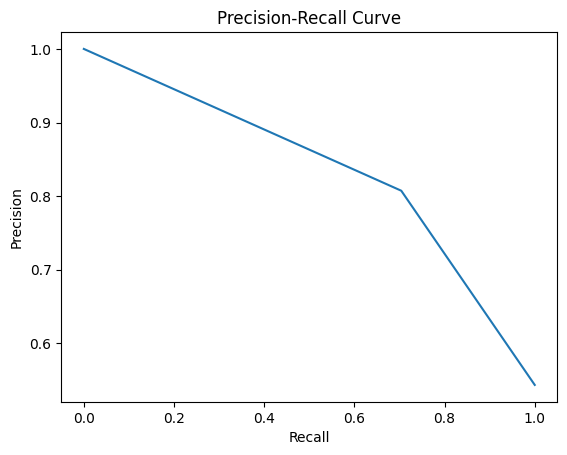

In [ ]:
svm_precision, svm_recall, thresholds = precision_recall_curve(y_test, pred)
plt.plot(svm_recall, svm_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
print(roc_auc_score(y_test, pred))

0.752


In [ ]:
f1_score(y_test, pred)

0.7521367521367521

In [ ]:
print(recall_score(y_test, pred))
print(precision_score(y_test,pred))

0.704
0.8073394495412844


## XGBoost

In [ ]:
param_grid = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.1, 0.01, 0.05],
    'model__n_estimators': [100, 200, 500, 1000],
    'model__subsample': [0.6,0.8],
}

In [ ]:
xgb_pipeline = Pipeline([('imputer', impute), ('model', xgb.XGBClassifier(learning_rate=0.01,max_depth=5,n_estimators=500,scale_pos_weight=1.2,subsample=0.6))])

In [ ]:
grid_search = GridSearchCV(estimator=xgb_pipeline,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           verbose=3,
                           n_jobs=-1)

In [ ]:
#grid_search.fit(x_train,y_train)

In [ ]:
#print(grid_search.best_params_)

In [ ]:
xgb_pipeline.fit(x_train,y_train)
pred = xgb_pipeline.predict_proba(x_test)

In [ ]:
y_prob = (pred > 0.3).astype(int)[:,1]
cr = classification_report(y_test, y_prob)

print(cr)

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       105
           1       0.83      0.94      0.88       125

    accuracy                           0.86       230
   macro avg       0.87      0.85      0.86       230
weighted avg       0.87      0.86      0.86       230



Text(0.5, 1.0, 'XGBoost CM')

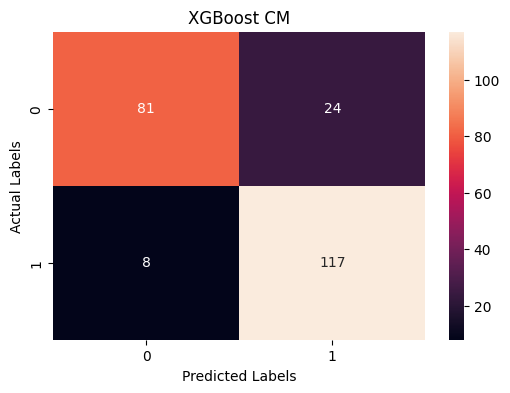

In [ ]:
plt.figure(figsize=(6, 4))
xgb_cm = confusion_matrix(y_test, y_prob)


sns.heatmap(xgb_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost CM')

In [ ]:
false_negatives = x_test[(y_test == 1) & (y_prob == 0)]
print(false_negatives['ST slope'])
print(false_negatives['chest pain type'])


376     1
708     1
1       2
729     1
441     1
761     1
657     1
1171    1
Name: ST slope, dtype: int64
376     3
708     4
1       3
729     4
441     3
761     2
657     4
1171    4
Name: chest pain type, dtype: int64


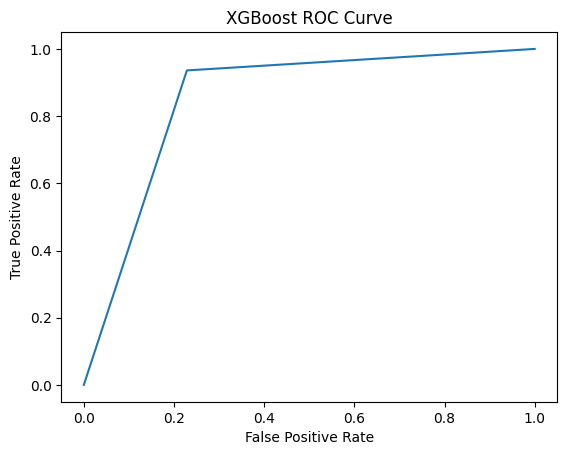

In [ ]:
xgb_fpr, xgb_tpr, threshold = roc_curve(y_test, y_prob)
plt.plot(xgb_fpr, xgb_tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.show()

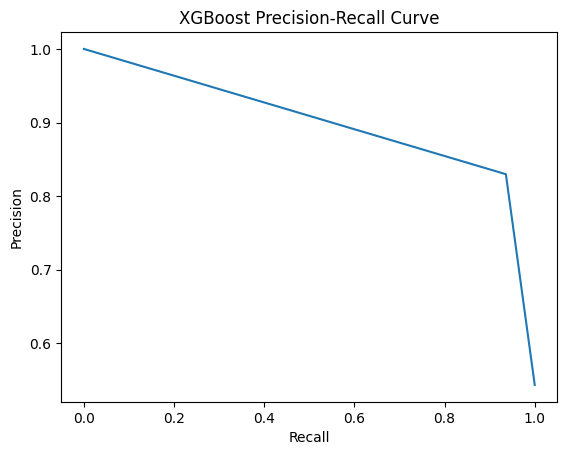

In [ ]:
xgb_precision, xgb_recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(xgb_recall, xgb_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Precision-Recall Curve')
plt.show()

In [ ]:
print(roc_auc_score(y_test, y_prob))

0.8537142857142858


 97%|=================== | 222/230 [00:20<00:00]       

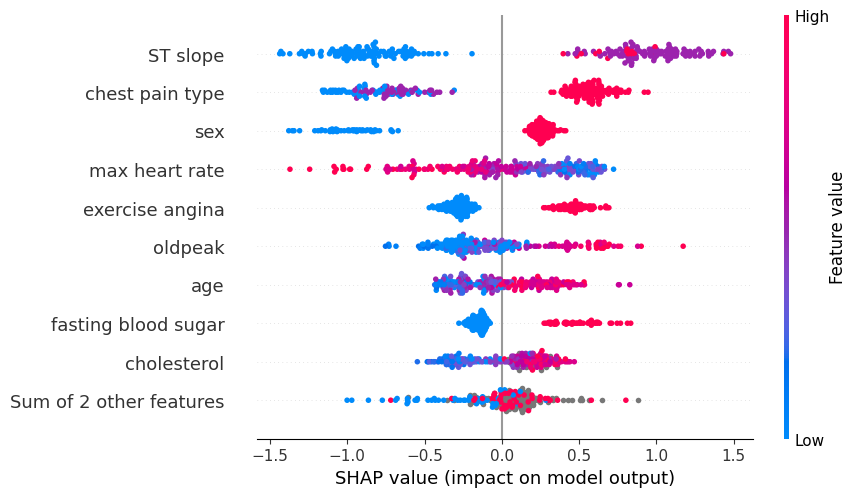

In [ ]:
explainer = shap.Explainer(xgb_pipeline.named_steps['model'],x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values)

In [ ]:
f1_score(y_test, y_prob)

0.8796992481203008

In [ ]:
print(recall_score(y_test, y_prob))
print(precision_score(y_test,y_prob))

0.936
0.8297872340425532


## Neural Network

In [ ]:
def model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(units = hp.Choice('units', [8,16,32,64,128]), activation='relu', kernel_regularizer=regularizers.l2(0.001)))
  model.add(keras.layers.Dense(units=hp.Choice('units_2', [4,8,16,32,64]),activation='relu', kernel_regularizer=regularizers.l2(0.001)
    ))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(units=1, activation='sigmoid'))
  optimiser = tf.keras.optimizers.Adam(hp.Float('learning_rate',1e-4,1e-2,sampling='log'))
  model.compile(optimizer=optimiser, loss='binary_crossentropy',metrics=['recall'])
  return model



In [ ]:
tuner = keras_tuner.RandomSearch(
    model,
    objective='recall',
    max_trials=25,
    directory='comprehensive_sets()'

)

Reloading Tuner from comprehensive_sets()/untitled_project/tuner0.json


In [ ]:
callback = tf.keras.callbacks.EarlyStopping(patience=10)
tuner.search(x_train_scaled,y_train, epochs=40,batch_size=16, validation_data=(x_test_scaled,y_test), callbacks=[callback])

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
model = tuner.hypermodel.build(best_hp)
model.fit(x_train_scaled,y_train, epochs=50,batch_size=16,validation_data=(x_test_scaled,y_test), callbacks=[callback])

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.7176 - recall: 0.6649 - val_loss: 0.7128 - val_recall: 0.8880
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7125 - recall: 0.7513 - val_loss: 0.7080 - val_recall: 0.9680
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7051 - recall: 0.8586 - val_loss: 0.7036 - val_recall: 0.9840
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7012 - recall: 0.9031 - val_loss: 0.6996 - val_recall: 0.9920
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6990 - recall: 0.8953 - val_loss: 0.6957 - val_recall: 0.9920
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6936 - recall: 0.9215 - val_loss: 0.6914 - val_recall: 0.9680
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6903 - recall: 0.9476 - val_loss: 0.6867 - val_recall: 0.9520
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6809 - recall: 0.9319 - val_loss: 0.6823 - val_recall: 0.9440
Epoch 9/50
43/43 ━━━━━━

In [ ]:
pred = model.predict(x_test_scaled)
preds = (pred > 0.35).astype(int)
print(f"CR: {classification_report(y_test, preds)}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
CR:               precision    recall  f1-score   support

           0       0.75      0.53      0.62       105
           1       0.68      0.85      0.76       125

    accuracy                           0.70       230
   macro avg       0.72      0.69      0.69       230
weighted avg       0.71      0.70      0.70       230



In [ ]:
#recall_score = cross_val_score(model, X, Y, cv=10,scoring='recall')
#precision_score = cross_val_score(model,X,Y,cv=10,scoring='precision')
#accuracy_score = cross_val_score(model,X,Y,cv=10,scoring='accuracy')
#print(f"Recall = {recall_score.mean()}, \nPrecision = {precision_score.mean()}, \nAccuracy = {accuracy_score.mean()}")

Text(0.5, 1.0, 'Neural Network CM')

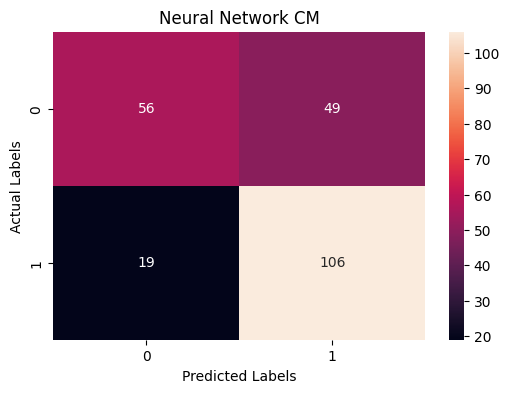

In [ ]:
plt.figure(figsize=(6, 4))
nn_cm = confusion_matrix(y_test, preds)


sns.heatmap(nn_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Neural Network CM')

In [ ]:
nn_precision, nn_recall, thresholds = precision_recall_curve(y_test, preds)

In [ ]:
nn_fpr, nn_tpr, threshold = roc_curve(y_test, preds)


In [ ]:
f1_score(y_test, preds)

0.7571428571428571

In [ ]:
print(roc_auc_score(y_test, preds))

0.6906666666666667


In [ ]:
print(recall_score(y_test, preds))
print(precision_score(y_test,preds))

0.848
0.6838709677419355


## Random Forest

In [ ]:
rf_pipeline = Pipeline([('imputer', impute), ('model', RandomForestClassifier(criterion='gini',max_depth=7,min_samples_leaf=2,min_samples_split=3,n_estimators=100))])

In [ ]:
param_grid = {
    'model__max_depth': [3, 5, 7, 10],
    'model__criterion': ['gini','entropy'],
    'model__n_estimators': [100, 200, 500, 1000],
    'model__min_samples_split': [2,3,5,10],
    'model__min_samples_leaf': [1,2,4],
}

grid_search = GridSearchCV(estimator=rf_pipeline,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           verbose=3,
                           n_jobs=-1)

In [ ]:
#grid_search.fit(x_train,y_train)

In [ ]:
#print(grid_search.best_params_)

In [ ]:
rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', IterativeImputer(random_state=10)),
                ('model',
                 RandomForestClassifier(max_depth=7, min_samples_leaf=2,
                                        min_samples_split=3))])

In [ ]:
pred = rf_pipeline.predict(x_test)

In [ ]:
proba = rf_pipeline.predict_proba(x_test)
y_prob = (proba > 0.32).astype(int)[:,1]


In [ ]:
cr = classification_report(y_test, y_prob)
print(cr)

              precision    recall  f1-score   support

           0       0.90      0.75      0.82       105
           1       0.82      0.93      0.87       125

    accuracy                           0.85       230
   macro avg       0.86      0.84      0.84       230
weighted avg       0.85      0.85      0.85       230



In [ ]:
score = cross_val_score(rf_pipeline, X, Y, cv=10,scoring='recall')
print(f"Recall: {score.mean()}")

Recall: 0.8731764705882353


Text(0.5, 1.0, 'Random Forest Confusion Matrix')

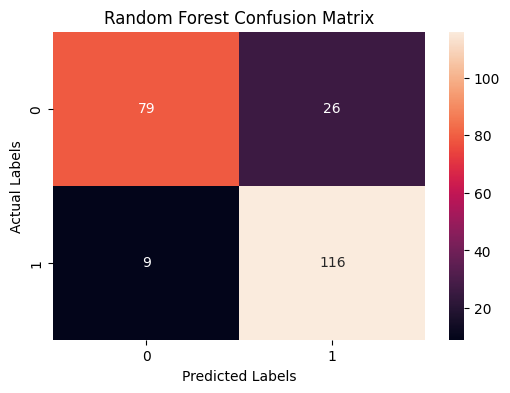

In [ ]:
plt.figure(figsize=(6, 4))
rf_cm = confusion_matrix(y_test, y_prob)


sns.heatmap(rf_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Random Forest Confusion Matrix')

In [ ]:

rf_precision, rf_recall, thresholds = precision_recall_curve(y_test, y_prob)

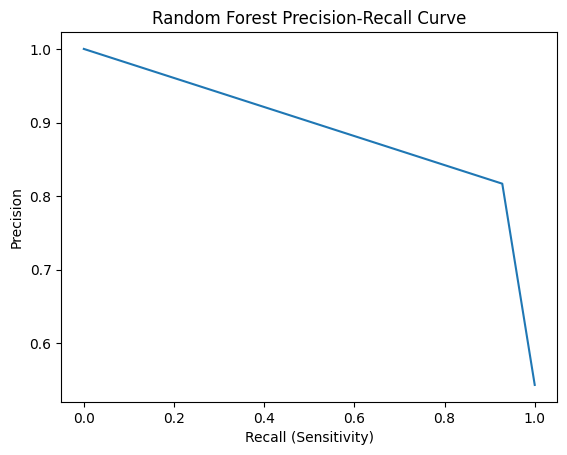

In [ ]:
plt.plot(rf_recall, rf_precision)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Random Forest Precision-Recall Curve')
plt.show()

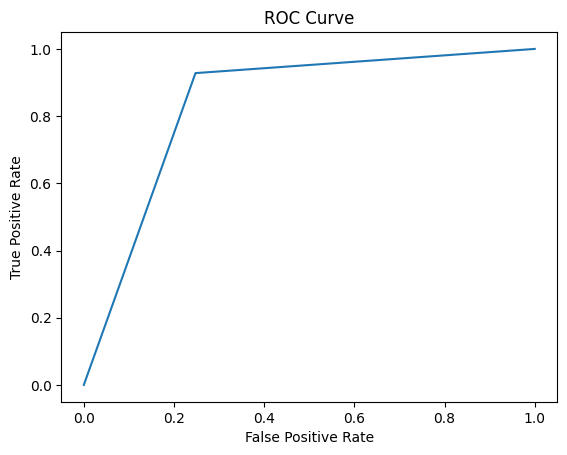

In [ ]:
rf_fpr, rf_tpr, threshold = roc_curve(y_test, y_prob)
plt.plot(rf_fpr, rf_tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

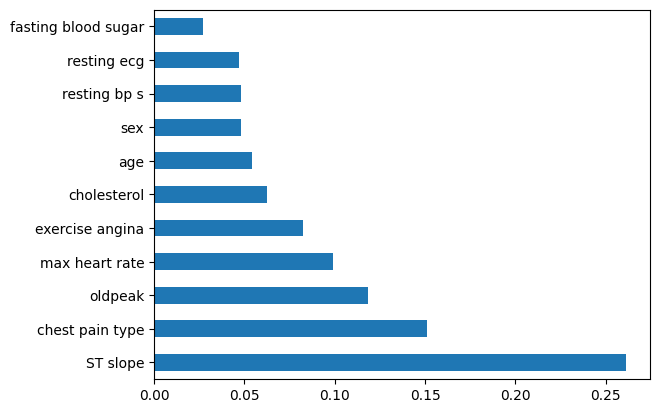

In [ ]:
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.show()

In [ ]:
f1_score(y_test, y_prob)

0.8689138576779026

In [ ]:
print(roc_auc_score(y_test, y_prob))

0.8401904761904762


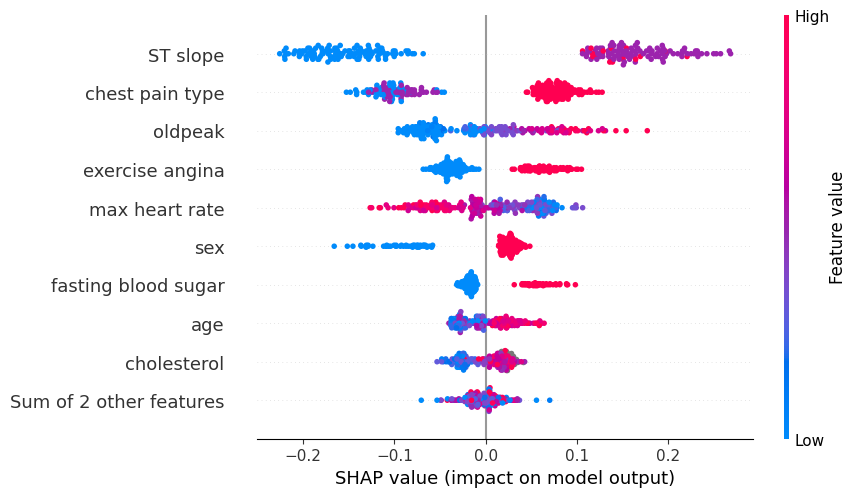

In [ ]:
explainer = shap.Explainer(rf_pipeline.named_steps['model'],x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values[:,:,1])

In [ ]:
print(recall_score(y_test, y_prob))
print(precision_score(y_test, y_prob))

0.928
0.8169014084507042


## Combined Graphs

In [ ]:
plt.plot(rf_fpr, rf_tpr, color='red', label='RF Model')
plt.plot(nn_fpr, nn_tpr, color='blue', label='NN Model')
plt.plot(svm_fpr, svm_tpr, color='green', label='SVM Model')
plt.plot(xgb_fpr, xgb_tpr, color='orange', label='XGBoost Model')
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
plt.plot(rf_recall, rf_precision, color='red', label='RF Model')
plt.plot(nn_recall, nn_precision, color='blue', label='NN Model')
plt.plot(svm_recall, svm_precision, color='green', label='SVM Model')
plt.plot(xgb_recall, xgb_precision, color='orange', label='XGBoost Model')
plt.legend()
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(rf_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Random Forest')

plt.subplot(2, 2, 2)
sns.heatmap(nn_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Neural Network')

plt.subplot(2, 2, 3)
sns.heatmap(svm_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('SVM')

plt.subplot(2, 2, 4)
sns.heatmap(xgb_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost')
plt.suptitle("Confusion Matrices",fontsize=20,fontweight='bold')
plt.show()

In [ ]:
plt.title("RF SHAP Beeswarm")
explainer = shap.Explainer(rf_pipeline.named_steps['model'],x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values[:,:,1])

plt.title("XGB SHAP Beeswarm")
explainer = shap.Explainer(xgb_pipeline.named_steps['model'],x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values)


# Minimized Dataset

## Imports

In [ ]:
%reset -f
!pip install keras-tuner --upgrade
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
import sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score, roc_curve, f1_score
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.svm import SVC
import seaborn as sns
import shap
import tensorflow as tf
import keras
import keras_tuner
from tensorflow.keras import regularizers
from sklearn.metrics import precision_recall_curve

## Data Handling

In [ ]:
df = pd.read_csv('heart_statlog_cleveland_hungary_final.csv', header=0)
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [ ]:

df = df.drop(['max heart rate','oldpeak','ST slope','resting ecg'], axis=1)

In [ ]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,exercise angina,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.387395,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.487360,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,1.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,1.000000,1.000000


In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,exercise angina,target
0,40,1,2,140,289,0,0,0
1,49,0,3,160,180,0,0,1
2,37,1,2,130,283,0,0,0
3,48,0,4,138,214,0,1,1
4,54,1,3,150,195,0,0,0
...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,1
1186,68,1,4,144,193,1,0,1
1187,57,1,4,130,131,0,1,1
1188,57,0,2,130,236,0,0,1


In [ ]:
df[df['resting bp s'] == 0]

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,exercise angina,target
450,55,1,3,0,0,0,0,1


In [ ]:
df[df['cholesterol'] == 0]

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,exercise angina,target
294,65,1,4,115,0,0,1,1
295,32,1,1,95,0,1,0,1
296,61,1,4,105,0,1,1,1
297,50,1,4,145,0,1,1,1
298,57,1,4,110,0,1,1,1
...,...,...,...,...,...,...,...,...
515,43,1,4,122,0,0,0,1
516,63,1,3,130,0,1,0,0
519,48,1,3,102,0,1,1,1
536,56,1,4,130,0,0,1,1


In [ ]:
df.loc[df['cholesterol'] == 0, 'cholesterol'] = np.nan
df.drop(450, inplace=True)

In [ ]:
scaled_features = ['age','resting bp s','fasting blood sugar','cholesterol']
scaler = StandardScaler()
ct = ColumnTransformer([('scaler', scaler, scaled_features )], remainder='passthrough',force_int_remainder_cols=False)

In [ ]:
X,Y = df.drop('target', axis=1), df['target']
Y
x_train, x_test, y_train, y_test = train_test_split(X,Y, random_state=10, test_size=0.25)

In [ ]:
impute = IterativeImputer(random_state = 10)
impute.set_output(transform="pandas")
x_train_scaled = impute.fit_transform(x_train)
x_test_scaled = impute.transform(x_test)
x_train_scaled = ct.fit_transform(x_train_scaled)
x_test_scaled = ct.transform(x_test_scaled)


## XGBoost

In [ ]:
param_grid = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.1, 0.01, 0.05],
    'model__n_estimators': [100, 200, 500, 1000],
    'model__subsample': [0.6, 0.8]
}

In [ ]:
xgb_pipeline = Pipeline([('imputer', impute), ('model', xgb.XGBClassifier(scale_pos_weight=1.2,learning_rate=0.01,max_depth=3,n_estimators=200,subsample=0.6,colsample_bytree=0.3))])

In [ ]:
grid_search = GridSearchCV(estimator=xgb_pipeline,
                           param_grid=param_grid,
                           scoring='average_precision',
                           cv=5,
                           verbose=3,
                           n_jobs=-1)

In [ ]:
#grid_search.fit(x_train,y_train)
#print(grid_search.best_params_)

In [ ]:
xgb_pipeline.fit(x_train,y_train)
pred = xgb_pipeline.predict_proba(x_test)
y_prob = (pred > 0.4).astype(int)[:,1]
cr = classification_report(y_test, y_prob)
print(cr)

              precision    recall  f1-score   support

           0       0.96      0.46      0.62       105
           1       0.68      0.98      0.80       123

    accuracy                           0.74       228
   macro avg       0.82      0.72      0.71       228
weighted avg       0.81      0.74      0.72       228



In [ ]:
xgb_precision, xgb_recall, thresholds = precision_recall_curve(y_test, y_prob)

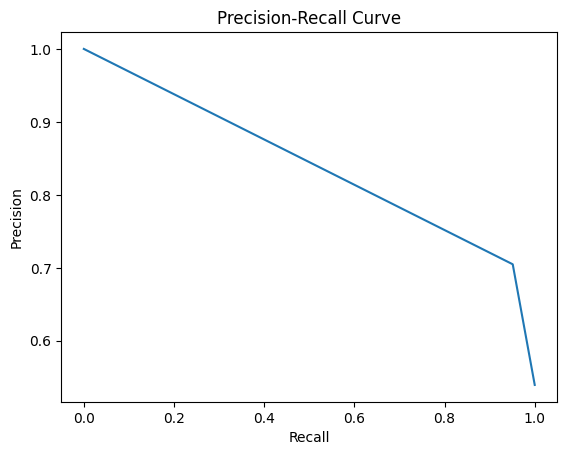

In [ ]:
plt.plot(xgb_recall, xgb_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
importances = xgb_pipeline.named_steps['model'].feature_importances_
print(importances)

[0.05399863 0.17438193 0.23331872 0.02400135 0.0390729  0.05888871
 0.4163377 ]


In [ ]:
explainer = shap.Explainer(xgb_pipeline.named_steps['model'],x_test)
shap_values = explainer(x_test)

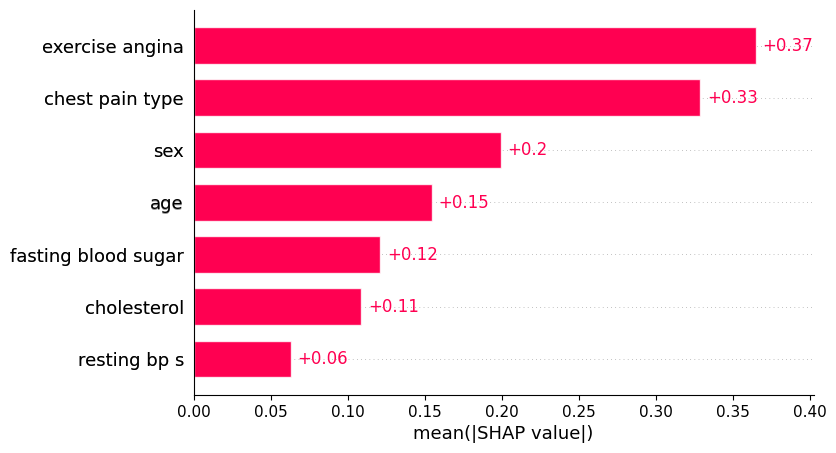

In [ ]:
shap.plots.bar(shap_values)

Text(0.5, 1.0, 'XGBoost CM')

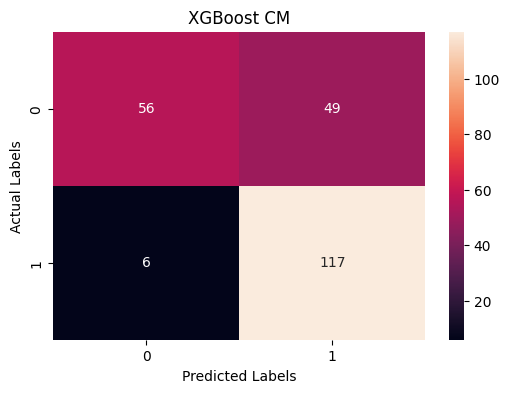

In [ ]:
plt.figure(figsize=(6, 4))
xgb_cm = confusion_matrix(y_test, y_prob)


sns.heatmap(xgb_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost CM')

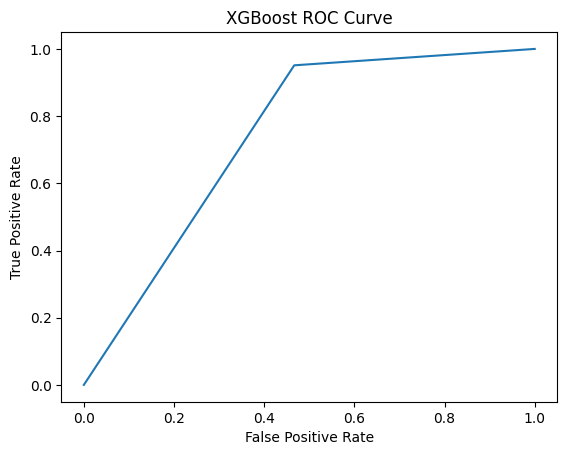

In [ ]:
xgb_fpr, xgb_tpr, threshold = roc_curve(y_test, y_prob)
plt.plot(xgb_fpr, xgb_tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.show()

In [ ]:
print(roc_auc_score(y_test, y_prob))
f1_score(y_test,y_prob)

0.7422764227642276


0.8096885813148789

In [ ]:
print(recall_score(y_test, y_prob))
print(precision_score(y_test, y_prob))

0.9512195121951219
0.7048192771084337


## Random Forest

In [ ]:
rf_pipeline = Pipeline([('imputer', impute), ('model', RandomForestClassifier(criterion='gini',max_depth=7,min_samples_leaf=4,min_samples_split=3,n_estimators=200))])

In [ ]:
param_grid = {
    'model__max_depth': [3, 5, 7, 10],
    'model__criterion': ['gini','entropy'],
    'model__n_estimators': [100, 200, 500],
    'model__min_samples_split': [2,3,5],
    'model__min_samples_leaf': [1,2,4],
}

grid_search = GridSearchCV(estimator=rf_pipeline,
                           param_grid=param_grid,
                           scoring='recall',
                           cv=5,
                           verbose=3,
                           n_jobs=-1)

In [ ]:
#grid_search.fit(x_test,y_test)

In [ ]:
#print(grid_search.best_params_)

In [ ]:
rf_pipeline.fit(x_test,y_test)
pred = rf_pipeline.predict(x_test)
cr = classification_report(y_test, pred)
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.90      0.90       105
           1       0.91      0.93      0.92       123

    accuracy                           0.91       228
   macro avg       0.91      0.91      0.91       228
weighted avg       0.91      0.91      0.91       228



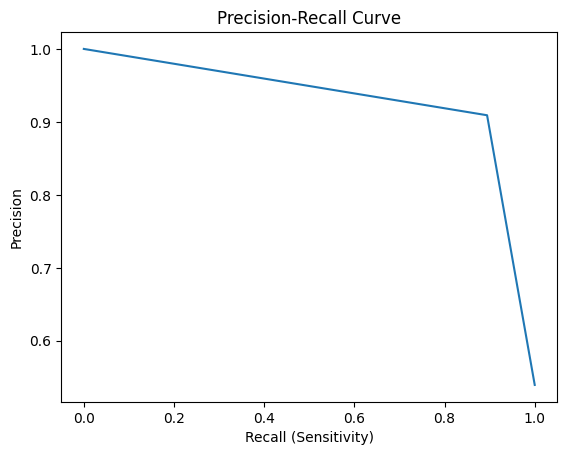

In [ ]:
y_probs = rf_pipeline.predict_proba(x_test)[:, 1]

rf_precision, rf_recall, thresholds = precision_recall_curve(y_test, pred)
plt.plot(rf_recall, rf_precision)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

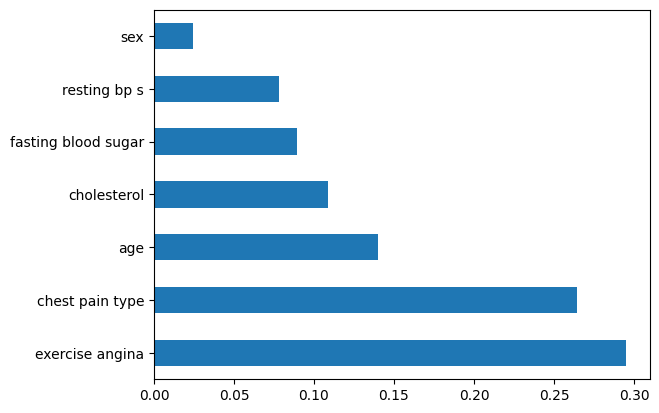

In [ ]:
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.show()

Text(0.5, 1.0, 'Random Forest Confusion Matrix')

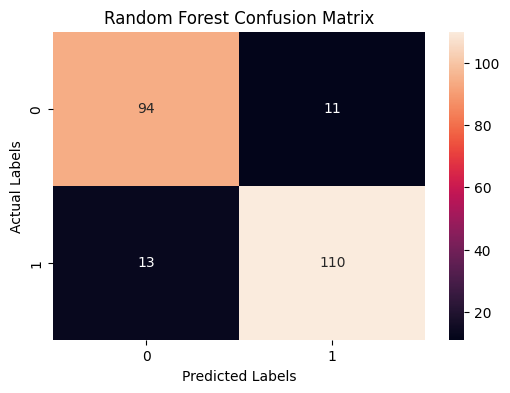

In [ ]:
plt.figure(figsize=(6, 4))
rf_cm = confusion_matrix(y_test, pred)


sns.heatmap(rf_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Random Forest Confusion Matrix')

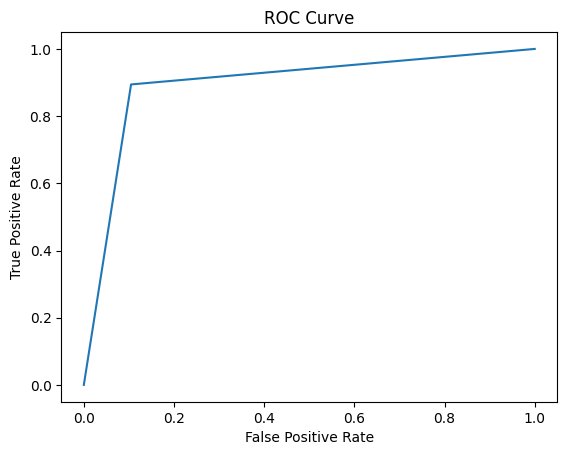

In [ ]:
rf_fpr, rf_tpr, threshold = roc_curve(y_test, pred)
plt.plot(rf_fpr, rf_tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
print(roc_auc_score(y_test, pred))
f1_score(y_test,pred)

0.8947735191637631


0.9016393442622951

In [ ]:
print(recall_score(y_test, pred))
print(precision_score(y_test,pred))

0.8943089430894309
0.9090909090909091


## SVM

In [ ]:
param_grid = {
    'model__C': [0.1,1,10,100],
    'model__kernel': ['poly','rbf'],
    'model__degree': [2,3,4],
    'model__gamma': ['scale','auto',0.1,0.01],
}

svm_pipeline = Pipeline([('imputer', impute),('preprocessor', ct), ('model', SVC(C=1,degree=2,gamma=0.01,kernel='rbf', probability=True))])

In [ ]:
grid_search = GridSearchCV(estimator=svm_pipeline,
                           param_grid=param_grid,
                           scoring='average_precision',
                           cv=5,
                           verbose=3,
                           n_jobs=-1)

#grid_search.fit(x_train,y_train)

In [ ]:
#print(grid_search.best_params_)

In [ ]:
svm_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', IterativeImputer(random_state=10)),
                ('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['age', 'resting bp s',
                                                   'fasting blood sugar',
                                                   'cholesterol'])])),
                ('model', SVC(C=1, degree=2, gamma=0.01, probability=True))])

In [ ]:
pred = svm_pipeline.predict(x_test)
cr = classification_report(y_test, pred)
print(cr)

              precision    recall  f1-score   support

           0       0.85      0.70      0.77       105
           1       0.78      0.89      0.83       123

    accuracy                           0.81       228
   macro avg       0.82      0.80      0.80       228
weighted avg       0.81      0.81      0.80       228



In [ ]:
score = cross_val_score(svm_pipeline, X, Y, cv=10,scoring='recall')
print(f"Recall: {score.mean()}")

Recall: 0.8296862745098039


Text(0.5, 1.0, 'XGBoost CM')

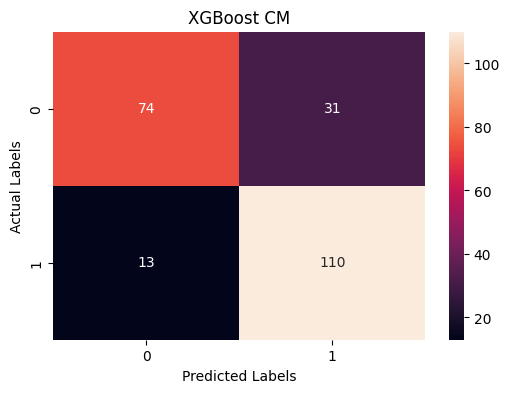

In [ ]:
plt.figure(figsize=(6, 4))
svm_cm = confusion_matrix(y_test, pred)


sns.heatmap(svm_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost CM')

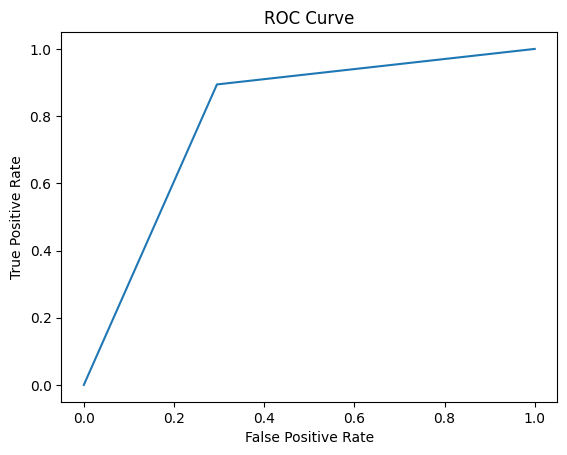

In [ ]:
svm_fpr, svm_tpr, threshold = roc_curve(y_test, pred)
plt.plot(svm_fpr, svm_tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

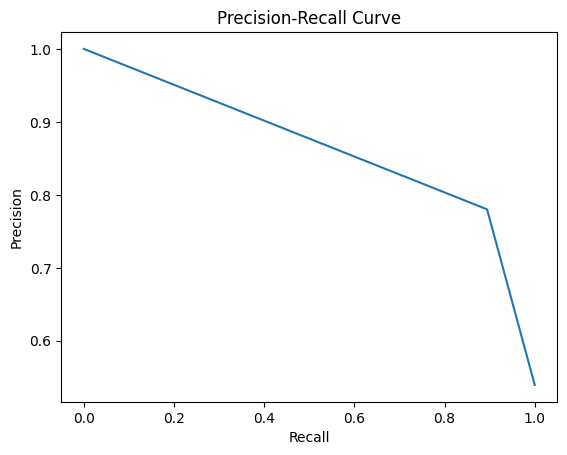

In [ ]:
svm_precision, svm_recall, thresholds = precision_recall_curve(y_test, pred)
plt.plot(svm_recall, svm_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
print(roc_auc_score(y_test, pred))
f1_score(y_test,pred)

0.7995354239256678


0.8333333333333334

In [ ]:
print(recall_score(y_test, pred))
print(precision_score(y_test,pred))

0.8943089430894309
0.7801418439716312


## Neural Network

In [ ]:
def model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(units = hp.Choice('units', [8,16,32,64,128]), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
  model.add(keras.layers.Dense(units=hp.Choice('units_2', [4,8,16,32,64]),activation='relu', kernel_regularizer=regularizers.l2(0.01)
    ))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(units=1, activation='sigmoid'))
  optimiser = tf.keras.optimizers.Adam(hp.Float('learning_rate',1e-4,1e-2,sampling='log'))
  model.compile(optimizer=optimiser, loss='binary_crossentropy',metrics=['recall'])
  return model



In [ ]:
tuner = keras_tuner.RandomSearch(
    model,
    objective='val_loss',
    max_trials=25,
    directory='minimal_set'

)

callback = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tuner.search(x_train_scaled,y_train, epochs=50,batch_size=16, validation_data=(x_test_scaled,y_test), callbacks=[callback])

Reloading Tuner from minimal_set/untitled_project/tuner0.json


In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hp)
model.fit(x_train_scaled,y_train, epochs=50,batch_size=16,validation_data=(x_test_scaled,y_test), callbacks=[callback])

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.8214 - recall: 0.8105 - val_loss: 0.5727 - val_recall: 0.9024
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5760 - recall: 0.8342 - val_loss: 0.5155 - val_recall: 0.9106
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5307 - recall: 0.8263 - val_loss: 0.4964 - val_recall: 0.8943
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5204 - recall: 0.8395 - val_loss: 0.5026 - val_recall: 0.9350
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5307 - recall: 0.8132 - val_loss: 0.4640 - val_recall: 0.8455
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5002 - recall: 0.8263 - val_loss: 0.4718 - val_recall: 0.7967
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5012 - recall: 0.8158 - val_loss: 0.4526 - val_recall: 0.8618
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4887 - recall: 0.8395 - val_loss: 0.4692 - val_recall: 0.8862
Epoch 9/50
43/43 ━━━━━━

In [ ]:
pred = model.predict(x_test_scaled)
preds = (pred > 0.5).astype(int)
print(f"CR: {classification_report(y_test, preds)}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
CR:               precision    recall  f1-score   support

           0       0.82      0.77      0.79       105
           1       0.81      0.85      0.83       123

    accuracy                           0.82       228
   macro avg       0.82      0.81      0.81       228
weighted avg       0.82      0.82      0.82       228



Text(0.5, 1.0, 'Neural Network CM')

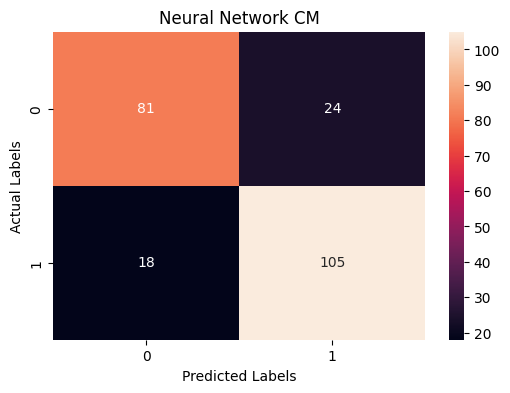

In [ ]:
plt.figure(figsize=(6, 4))
nn_cm = confusion_matrix(y_test, preds)


sns.heatmap(nn_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Neural Network CM')

In [ ]:
nn_precision, nn_recall, thresholds = precision_recall_curve(y_test, preds)

In [ ]:
nn_fpr, nn_tpr, threshold = roc_curve(y_test, preds)

In [ ]:
f1_score(y_test, preds)

0.8333333333333334

In [ ]:
print(roc_auc_score(y_test, preds))

0.8125435540069686


In [ ]:
print(recall_score(y_test, preds))
print(precision_score(y_test,preds))

0.8536585365853658
0.813953488372093


## Combined Graphs

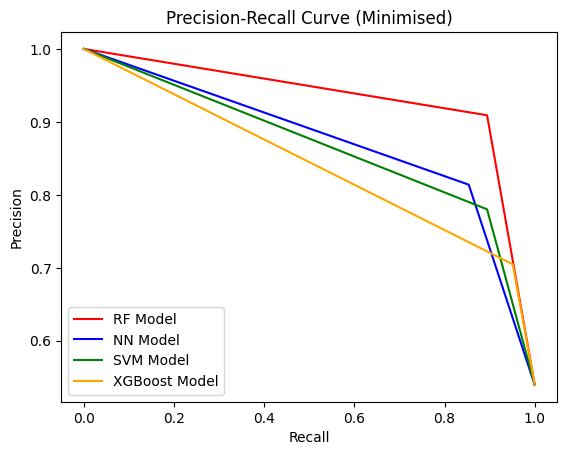

In [ ]:
plt.plot(rf_recall, rf_precision, color='red', label='RF Model')
plt.plot(nn_recall, nn_precision, color='blue', label='NN Model')
plt.plot(svm_recall, svm_precision, color='green', label='SVM Model')
plt.plot(xgb_recall, xgb_precision, color='orange', label='XGBoost Model')
plt.legend()
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Minimised)')
plt.show()

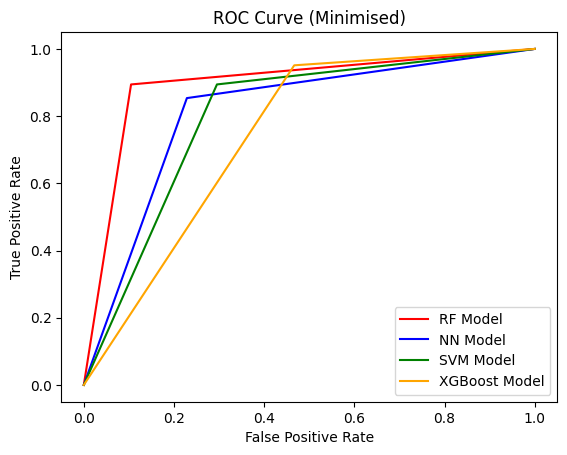

In [ ]:
plt.plot(rf_fpr, rf_tpr, color='red', label='RF Model')
plt.plot(nn_fpr, nn_tpr, color='blue', label='NN Model')
plt.plot(svm_fpr, svm_tpr, color='green', label='SVM Model')
plt.plot(xgb_fpr, xgb_tpr, color='orange', label='XGBoost Model')
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Minimised)')
plt.show()

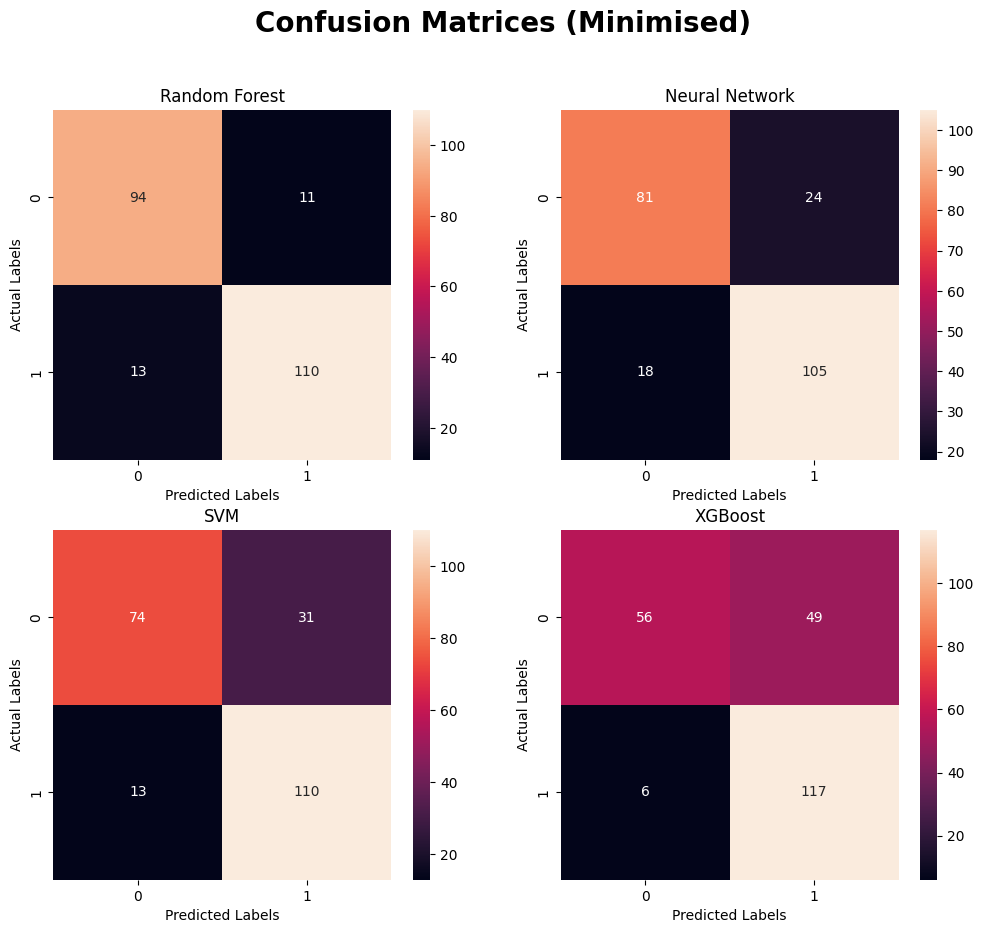

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(rf_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Random Forest')

plt.subplot(2, 2, 2)
sns.heatmap(nn_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Neural Network')

plt.subplot(2, 2, 3)
sns.heatmap(svm_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('SVM')

plt.subplot(2, 2, 4)
sns.heatmap(xgb_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost')
plt.suptitle("Confusion Matrices (Minimised)",fontsize=20,fontweight='bold')
plt.show()

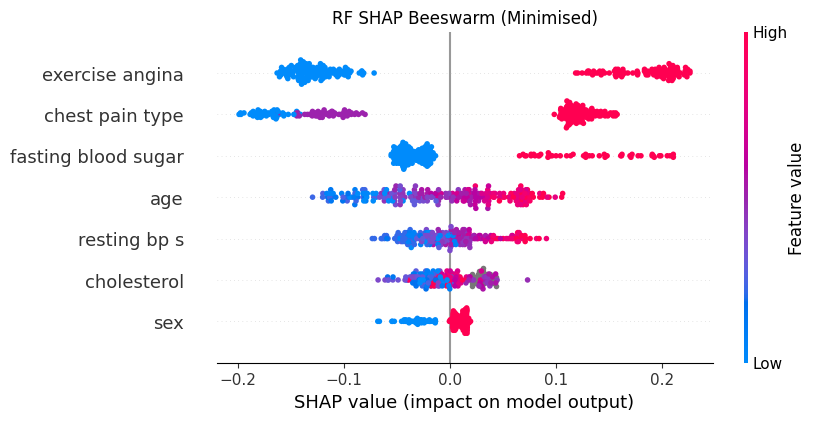

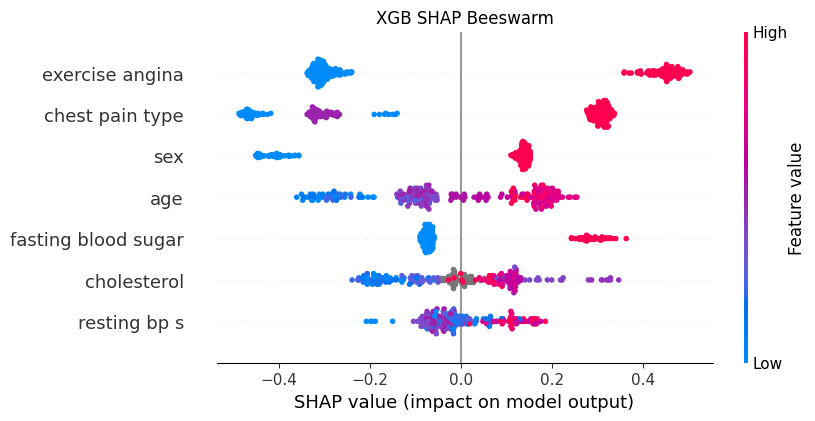

In [ ]:
plt.title("RF SHAP Beeswarm (Minimised)")
explainer = shap.Explainer(rf_pipeline.named_steps['model'],x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values[:,:,1])

plt.title("XGB SHAP Beeswarm")
explainer = shap.Explainer(xgb_pipeline.named_steps['model'],x_test)
shap_values = explainer(x_test)
shap.plots.beeswarm(shap_values)

# UCI Heart Disease(Multi Classification)

## Imports

In [ ]:
%reset -f
!pip install keras-tuner --upgrade
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, roc_curve, f1_score
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import seaborn as sns
import shap
import tensorflow as tf
import keras
import keras_tuner
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from tensorflow.keras import regularizers

## Data Handling

In [ ]:
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','num']

In [ ]:
cleveland = pd.read_csv('processed.cleveland.data', header=None,names=columns, na_values='?')
cleveland.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
hungarian = pd.read_csv('reprocessed.hungarian.data', header=None, names=columns,na_values='-9', delimiter=' ')
hungarian.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,294.000000,294.000000,294.000000,293.000000,271.000000,286.000000,293.000000,293.000000,293.000000,294.000000,104.000000,4.00,28.000000,294.000000
mean,47.826531,0.724490,2.982993,132.583618,250.848708,0.069930,0.218430,139.129693,0.303754,0.586054,1.894231,2.25,5.642857,0.792517
std,7.811812,0.447533,0.965117,17.626568,67.657711,0.255476,0.460868,23.589749,0.460665,0.908648,0.338995,4.50,1.615074,1.237006
min,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,82.000000,0.000000,0.000000,1.000000,0.00,3.000000,0.000000
25%,42.000000,0.000000,2.000000,120.000000,209.000000,0.000000,0.000000,122.000000,0.000000,0.000000,2.000000,0.00,5.250000,0.000000
50%,49.000000,1.000000,3.000000,130.000000,243.000000,0.000000,0.000000,140.000000,0.000000,0.000000,2.000000,0.00,6.000000,0.000000
75%,54.000000,1.000000,4.000000,140.000000,282.500000,0.000000,0.000000,155.000000,1.000000,1.000000,2.000000,2.25,7.000000,1.000000
max,66.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,190.000000,1.000000,5.000000,3.000000,9.00,7.000000,4.000000


In [ ]:
switzerland = pd.read_csv('processed.switzerland.data', header=None, names=columns,na_values='?')
switzerland.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,123.000000,123.000000,123.000000,121.000000,123.0,48.000000,122.000000,122.000000,122.000000,117.000000,106.000000,5.000000,71.000000,123.000000
mean,55.317073,0.918699,3.699187,130.206612,0.0,0.104167,0.360656,121.557377,0.442623,0.653846,1.801887,1.600000,5.788732,1.804878
std,9.032108,0.274414,0.688726,22.559151,0.0,0.308709,0.590077,25.977438,0.498745,1.056061,0.623658,0.547723,1.731354,1.013503
min,32.000000,0.000000,1.000000,80.000000,0.0,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,1.000000,3.000000,0.000000
25%,51.000000,1.000000,4.000000,115.000000,0.0,0.000000,0.000000,104.250000,0.000000,0.000000,1.000000,1.000000,3.000000,1.000000
50%,56.000000,1.000000,4.000000,125.000000,0.0,0.000000,0.000000,121.000000,0.000000,0.300000,2.000000,2.000000,7.000000,2.000000
75%,61.500000,1.000000,4.000000,145.000000,0.0,0.000000,1.000000,140.000000,1.000000,1.500000,2.000000,2.000000,7.000000,3.000000
max,74.000000,1.000000,4.000000,200.000000,0.0,1.000000,2.000000,182.000000,1.000000,3.700000,3.000000,2.000000,7.000000,4.000000


In [ ]:
va = pd.read_csv('processed.va.data', header=None, names=columns,na_values='?')
va.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,200.000000,200.000000,200.000000,144.000000,193.000000,193.000000,200.000000,147.000000,147.000000,144.000000,98.000000,2.0,34.000000,200.000000
mean,59.350000,0.970000,3.505000,133.763889,178.746114,0.352332,0.735000,122.795918,0.646259,1.320833,2.132653,0.0,6.294118,1.520000
std,7.811697,0.171015,0.795701,21.537733,114.035232,0.478939,0.683455,21.990328,0.479765,1.106236,0.667937,0.0,1.291685,1.219441
min,35.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000000,-0.500000,1.000000,0.0,3.000000,0.000000
25%,55.000000,1.000000,3.000000,120.000000,0.000000,0.000000,0.000000,109.000000,0.000000,0.000000,2.000000,0.0,6.000000,0.000000
50%,60.000000,1.000000,4.000000,130.000000,216.000000,0.000000,1.000000,120.000000,1.000000,1.500000,2.000000,0.0,7.000000,1.000000
75%,64.000000,1.000000,4.000000,147.000000,258.000000,1.000000,1.000000,140.000000,1.000000,2.000000,3.000000,0.0,7.000000,3.000000
max,77.000000,1.000000,4.000000,190.000000,458.000000,1.000000,2.000000,180.000000,1.000000,4.000000,3.000000,0.0,7.000000,4.000000


In [ ]:
datalist = [va,switzerland,hungarian,cleveland]
df = pd.concat(datalist, ignore_index=True)
df = df.reset_index(drop=True)
df = df.dropna(subset=['num'])

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,4.0,140.0,260.0,0.0,1.0,112.0,1.0,3.0,2.0,NaN,NaN,2.0
1,44.0,1.0,4.0,130.0,209.0,0.0,1.0,127.0,0.0,0.0,NaN,NaN,NaN,0.0
2,60.0,1.0,4.0,132.0,218.0,0.0,1.0,140.0,1.0,1.5,3.0,NaN,NaN,2.0
3,55.0,1.0,4.0,142.0,228.0,0.0,1.0,149.0,1.0,2.5,1.0,NaN,NaN,1.0
4,66.0,1.0,3.0,110.0,213.0,1.0,2.0,99.0,1.0,1.3,2.0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1.0
917,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2.0
918,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3.0
919,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1.0


In [ ]:
df[df['oldpeak'] == 0]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
1,44.0,1.0,4.0,130.0,209.0,0.0,1.0,127.0,0.0,0.0,NaN,NaN,NaN,0.0
6,65.0,1.0,4.0,150.0,236.0,1.0,1.0,105.0,1.0,0.0,NaN,NaN,NaN,3.0
10,56.0,1.0,2.0,126.0,166.0,0.0,1.0,140.0,0.0,0.0,NaN,NaN,NaN,0.0
15,62.0,1.0,4.0,120.0,220.0,0.0,1.0,86.0,0.0,0.0,NaN,NaN,NaN,0.0
19,60.0,1.0,4.0,152.0,0.0,0.0,1.0,118.0,1.0,0.0,NaN,NaN,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,56.0,1.0,2.0,120.0,240.0,0.0,0.0,169.0,0.0,0.0,3.0,0.0,3.0,0.0
912,63.0,0.0,4.0,124.0,197.0,0.0,0.0,136.0,1.0,0.0,2.0,0.0,3.0,1.0
913,41.0,1.0,2.0,120.0,157.0,0.0,0.0,182.0,0.0,0.0,1.0,0.0,3.0,0.0
919,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1.0


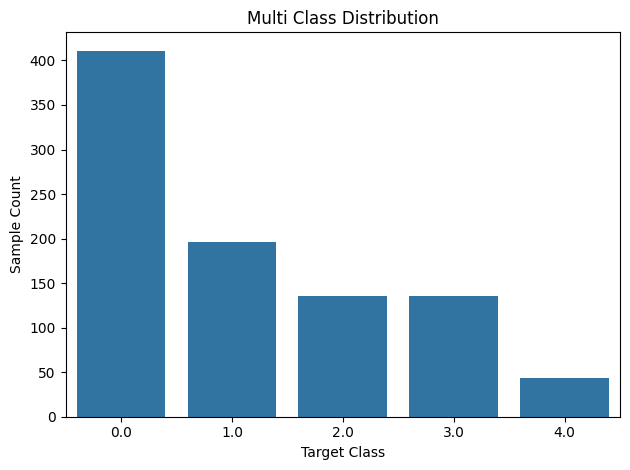

In [ ]:
sns.countplot(data=df, x='num')
plt.title("Multi Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

In [ ]:
df[df['num'] == 4].count()

,0
age,43
sex,43
cp,43
trestbps,40
chol,42
fbs,41
restecg,43
thalach,41
exang,41
oldpeak,41


In [ ]:
df[df['chol'] == 0]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
5,66.0,1.0,3.0,120.0,0.0,0.0,1.0,120.0,0.0,-0.5,1.0,NaN,NaN,0.0
7,60.0,1.0,3.0,180.0,0.0,0.0,1.0,140.0,1.0,1.5,2.0,NaN,NaN,0.0
8,60.0,1.0,3.0,120.0,0.0,NaN,0.0,141.0,1.0,2.0,1.0,NaN,NaN,3.0
11,59.0,1.0,4.0,140.0,0.0,0.0,1.0,117.0,1.0,1.0,2.0,NaN,NaN,1.0
12,62.0,1.0,4.0,110.0,0.0,0.0,0.0,120.0,1.0,0.5,2.0,NaN,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,70.0,1.0,4.0,115.0,0.0,0.0,1.0,92.0,1.0,0.0,2.0,NaN,7.0,1.0
319,70.0,1.0,4.0,140.0,0.0,1.0,0.0,157.0,1.0,2.0,2.0,NaN,7.0,3.0
320,72.0,1.0,3.0,160.0,0.0,NaN,2.0,114.0,0.0,1.6,2.0,2.0,NaN,0.0
321,73.0,0.0,3.0,160.0,0.0,0.0,1.0,121.0,0.0,0.0,1.0,NaN,3.0,1.0


In [ ]:
df.loc[df['chol'] == 0, 'chol'] = np.nan

In [ ]:
df['num'].describe()

,num
count,920.000000
mean,1.133696
std,1.258942
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,4.000000


In [ ]:
X,Y = df.drop('num', axis=1), df['num']
Y[Y == np.nan]

,num


In [ ]:
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']
df = pd.DataFrame(df, columns=columns)
X = df

In [ ]:
scaled_features = ['age','chol','trestbps','thalach','oldpeak']
scaler = StandardScaler()
ct = ColumnTransformer([('scaler', scaler, scaled_features )], remainder='passthrough',force_int_remainder_cols=False)

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,4.0,140.0,260.0,0.0,1.0,112.0,1.0,3.0,2.0,NaN,NaN
1,44.0,1.0,4.0,130.0,209.0,0.0,1.0,127.0,0.0,0.0,NaN,NaN,NaN
2,60.0,1.0,4.0,132.0,218.0,0.0,1.0,140.0,1.0,1.5,3.0,NaN,NaN
3,55.0,1.0,4.0,142.0,228.0,0.0,1.0,149.0,1.0,2.5,1.0,NaN,NaN
4,66.0,1.0,3.0,110.0,213.0,1.0,2.0,99.0,1.0,1.3,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
917,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
918,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0
919,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0


In [ ]:
df['sex'].dtype

dtype('float64')

In [ ]:
df.shape

(920, 13)

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,920.000000,920.000000,920.000000,861.000000,718.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,310.000000,434.000000
mean,53.510870,0.789130,3.250000,132.132404,246.832869,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.703226,5.087558
std,9.424685,0.408148,0.930969,19.066070,58.527062,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,1.046951,1.919075
min,28.000000,0.000000,1.000000,0.000000,85.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000
25%,47.000000,1.000000,3.000000,120.000000,210.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,54.000000,1.000000,4.000000,130.000000,239.500000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000
75%,60.000000,1.000000,4.000000,140.000000,276.750000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,9.000000,7.000000


In [ ]:
Y

,num
0,2.0
1,0.0
2,2.0
3,1.0
4,0.0
...,...
916,1.0
917,2.0
918,3.0
919,1.0


In [ ]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,4.0,140.0,260.0,0.0,1.0,112.0,1.0,3.0,2.0,NaN,NaN
1,44.0,1.0,4.0,130.0,209.0,0.0,1.0,127.0,0.0,0.0,NaN,NaN,NaN
2,60.0,1.0,4.0,132.0,218.0,0.0,1.0,140.0,1.0,1.5,3.0,NaN,NaN
3,55.0,1.0,4.0,142.0,228.0,0.0,1.0,149.0,1.0,2.5,1.0,NaN,NaN
4,66.0,1.0,3.0,110.0,213.0,1.0,2.0,99.0,1.0,1.3,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
917,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
918,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0
919,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.25,stratify=Y, random_state=10)

In [ ]:
impute = IterativeImputer(random_state=10)
impute.set_output(transform="pandas")
x_train_imputed = impute.fit_transform(x_train)
x_test_imputed = impute.transform(x_test)
x_train_scaled = ct.fit_transform(x_train_imputed)
x_test_scaled = ct.transform(x_test_imputed)

In [ ]:
sm = SMOTE(random_state = 10)
x_smote, y_smote = sm.fit_resample(x_train_scaled, y_train)

In [ ]:
print(y_train.unique())

[3. 1. 0. 4. 2.]


## XGBoost Algorithm

In [ ]:
xgb_pipeline = ImbPipeline([('imputer', impute),('smote', SMOTE(random_state=10)), ('model', xgb.XGBClassifier(objective='multi:softprob',num_class=Y.nunique(), gamma=0.1,learning_rate=0.01,max_depth=7,n_estimators=1000))])

In [ ]:
param_grid = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.1, 0.01, 0.05],
    'model__n_estimators': [100, 200, 500, 1000],
    'model__gamma': [0,0.1,0.5]
}

In [ ]:
grid_search = GridSearchCV(estimator=xgb_pipeline,
                           param_grid=param_grid,
                           scoring='recall_macro',
                           cv=5,
                           verbose=1,
                           n_jobs=-1)

In [ ]:
#grid_search.fit(x_train,y_train)

In [ ]:
#print(grid_search.best_params_)

lr = 0.1 n_est =100, max_depth=3

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
weights = compute_sample_weight(class_weight='balanced', y=y_smote)



In [ ]:
xgb_pipeline.fit(x_train,y_train)
score = cross_val_score(xgb_pipeline, X, Y, cv=10,scoring='recall_macro')

In [ ]:
joblib.dump(xgb_pipeline, 'models/multi_xgb.joblib')

['models/multi_xgb.joblib']

In [ ]:
print(f"Recall: {score.mean()}")

Recall: 0.35831366408516596


In [ ]:
preds = xgb_pipeline.predict_proba(x_test)[:,1]
y_prob = (preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_prob)}")

Accuracy: 0.4782608695652174


In [ ]:
print(f"CR: {classification_report(y_test, y_prob)}")

CR:               precision    recall  f1-score   support

         0.0       0.49      0.96      0.65       103
         1.0       0.37      0.22      0.28        49
         2.0       0.00      0.00      0.00        33
         3.0       0.00      0.00      0.00        34
         4.0       0.00      0.00      0.00        11

    accuracy                           0.48       230
   macro avg       0.17      0.24      0.19       230
weighted avg       0.30      0.48      0.35       230



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(0.5, 1.0, 'XGBoost CM')

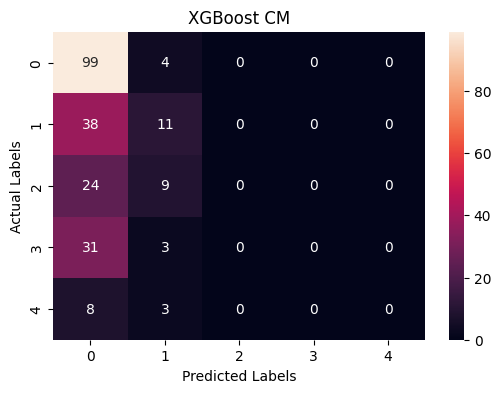

In [ ]:
plt.figure(figsize=(6, 4))
xgb_cm = confusion_matrix(y_test, y_prob)


sns.heatmap(xgb_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost CM')


## Neural Network Implementation

In [ ]:
def model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(units = hp.Choice('units', [8,16,32,64,128]), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
  model.add(keras.layers.Dense(units=hp.Choice('units_2', [4,8,16,32,64]),activation='relu', kernel_regularizer=regularizers.l2(0.01)
    ))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(units=5, activation='softmax'))
  optimiser = tf.keras.optimizers.Adam(hp.Float('learning_rate',1e-4,1e-2,sampling='log'))
  model.compile(optimizer=optimiser, loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  return model


In [ ]:
tuner = keras_tuner.RandomSearch(
    model,
    objective='val_loss',
    max_trials=25,
    directory='multi_class_dir'

)

Reloading Tuner from multi_class_dir/untitled_project/tuner0.json


In [ ]:
callback = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tuner.search(x_smote,y_smote, epochs=50,batch_size=16, validation_data=(x_test_scaled,y_test), callbacks=[callback])

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hp)
model.fit(x_smote,y_smote, epochs=50,batch_size=16,validation_data=(x_test_scaled,y_test), callbacks=[callback])

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2994 - loss: 1.7214 - val_accuracy: 0.4609 - val_loss: 1.4682
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3448 - loss: 1.5618 - val_accuracy: 0.4087 - val_loss: 1.3944
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3584 - loss: 1.4928 - val_accuracy: 0.4609 - val_loss: 1.2996
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3786 - loss: 1.4547 - val_accuracy: 0.4391 - val_loss: 1.3200
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3805 - loss: 1.4362 - val_accuracy: 0.4435 - val_loss: 1.2562
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3662 - loss: 1.4288 - val_accuracy: 0.4478 - val_loss: 1.2519
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3877 - loss: 1.3959 - val_accuracy: 0.4652 - val_loss: 1.2366
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3857 - loss: 1.3708 - val_accuracy: 0.4261 - val_loss:

In [ ]:
model.save('models/multi_nn.h5')
joblib.dump(ct, 'models/multi_ct.joblib')

['models/multi_ct.joblib']

In [ ]:
pred_probs = model.predict(x_test)
preds = np.argmax(pred_probs, axis=1)
print(f"CR:\n {classification_report(y_test, preds)}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
CR:
               precision    recall  f1-score   support

         0.0       0.41      0.61      0.49       103
         1.0       0.00      0.00      0.00        49
         2.0       0.00      0.00      0.00        33
         3.0       0.00      0.00      0.00        34
         4.0       0.05      0.36      0.09        11

    accuracy                           0.29       230
   macro avg       0.09      0.20      0.12       230
weighted avg       0.18      0.29      0.22       230



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(0.5, 1.0, 'XGBoost CM')

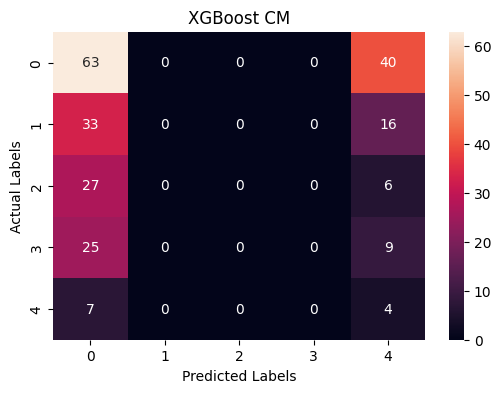

In [ ]:
plt.figure(figsize=(6, 4))
nn_cm = confusion_matrix(y_test, preds)


sns.heatmap(nn_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Neural Network CM')


## Random Forest Algorithm

In [ ]:
rf_pipeline = ImbPipeline([('imputer', impute),('smote', SMOTE(random_state=10)), ('model', RandomForestClassifier(criterion='gini',max_depth=3,min_samples_leaf=2,min_samples_split=2,n_estimators=200))])


In [ ]:
param_grid = {
    'model__max_depth': [3, 5, 7, 10],
    'model__criterion': ['gini','entropy'],
    'model__n_estimators': [100, 200, 500, 1000],
    'model__min_samples_split': [2,3,5,10],
    'model__min_samples_leaf': [1,2,4],
}

In [ ]:
grid_search = GridSearchCV(estimator=rf_pipeline,
                           param_grid=param_grid,
                           scoring='recall_macro',
                           cv=5,
                           verbose=3,
                           n_jobs=-1)

In [ ]:
rf_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', IterativeImputer(random_state=10)),
                ('smote', SMOTE(random_state=10)),
                ('model',
                 RandomForestClassifier(max_depth=3, min_samples_leaf=2,
                                        n_estimators=200))])

In [ ]:
joblib.dump(rf_pipeline, 'models/multi_rf.joblib')

['models/multi_rf.joblib']

In [ ]:
#print(grid_search.best_params_)

In [ ]:
pred = rf_pipeline.predict(x_test)

In [ ]:
cr = classification_report(y_test, pred)

print(cr)

              precision    recall  f1-score   support

         0.0       0.78      0.84      0.81       103
         1.0       0.38      0.20      0.27        49
         2.0       0.32      0.27      0.30        33
         3.0       0.30      0.29      0.30        34
         4.0       0.16      0.45      0.23        11

    accuracy                           0.53       230
   macro avg       0.39      0.41      0.38       230
weighted avg       0.53      0.53      0.52       230



In [ ]:
score = cross_val_score(rf_pipeline, X, Y, cv=10,scoring='recall_macro')

In [ ]:
print(f"Recall: {score.mean()}")

Recall: 0.3744070119012353


Text(0.5, 1.0, 'Random Forest CM')

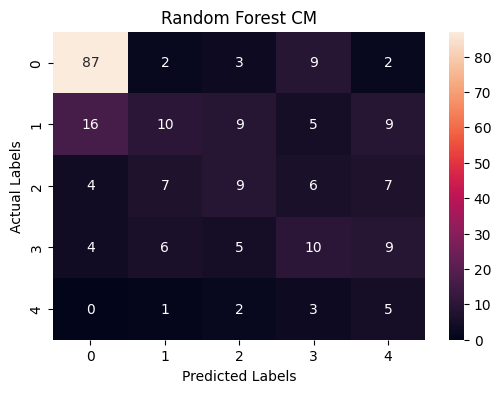

In [ ]:
plt.figure(figsize=(6, 4))
rf_cm = confusion_matrix(y_test, pred)


sns.heatmap(rf_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Random Forest CM')

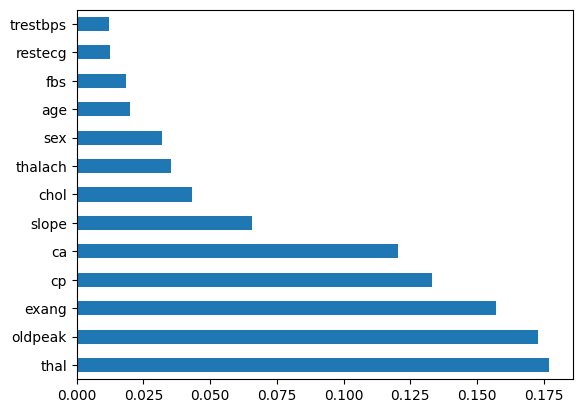

In [ ]:
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.show()

## Support Vector Machine

In [ ]:
svm_pipeline = ImbPipeline([('imputer', impute),('preprocessor', ct.set_output(transform="pandas")),('smote', SMOTE(random_state=10)) ,('model', SVC(C=0.1,degree=2,gamma='scale',kernel='rbf'))])

In [ ]:
param_grid = {
    'model__C': [0.1,1,10],
    'model__kernel': ['poly','rbf'],
    'model__degree': [2,3,4],
    'model__gamma': ['scale','auto',0.1,0.01],

}

In [ ]:
grid_search = GridSearchCV(estimator=svm_pipeline,
                           param_grid=param_grid,
                           scoring='recall_macro',
                           cv=5,
                           verbose=3,
                           n_jobs=-1,
                           error_score='raise')

In [ ]:
#grid_search.fit(x_train,y_train)

In [ ]:
#print(grid_search.best_params_)

In [ ]:
svm_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', IterativeImputer(random_state=10)),
                ('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['age', 'chol', 'trestbps',
                                                   'thalach', 'oldpeak'])])),
                ('smote', SMOTE(random_state=10)),
                ('model', SVC(C=0.1, degree=2))])

In [ ]:
joblib.dump(svm_pipeline, 'models/multi_svm.joblib')

['models/multi_svm.joblib']

In [ ]:
pred = svm_pipeline.predict(x_test)

In [ ]:
cr = classification_report(y_test, pred)

In [ ]:
score = cross_val_score(svm_pipeline, X, Y, cv=10,scoring='recall_macro')

In [ ]:
print(f"Recall: {score.mean()}")

Recall: 0.3886066761650843


In [ ]:
print(cr)

              precision    recall  f1-score   support

         0.0       0.80      0.76      0.78       103
         1.0       0.30      0.27      0.28        49
         2.0       0.18      0.06      0.09        33
         3.0       0.33      0.47      0.39        34
         4.0       0.14      0.36      0.21        11

    accuracy                           0.49       230
   macro avg       0.35      0.38      0.35       230
weighted avg       0.50      0.49      0.49       230



Text(0.5, 1.0, 'XGBoost CM')

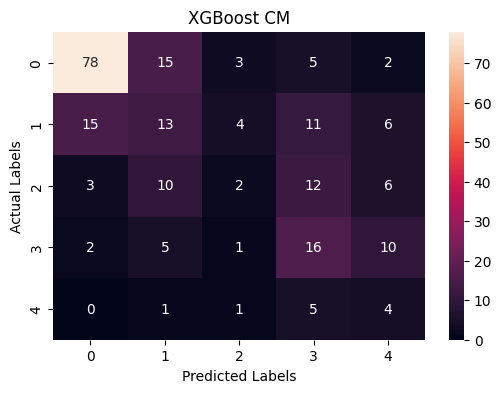

In [ ]:
plt.figure(figsize=(6, 4))
svm_cm = confusion_matrix(y_test, pred)


sns.heatmap(svm_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost CM')

## Confusion Matrices

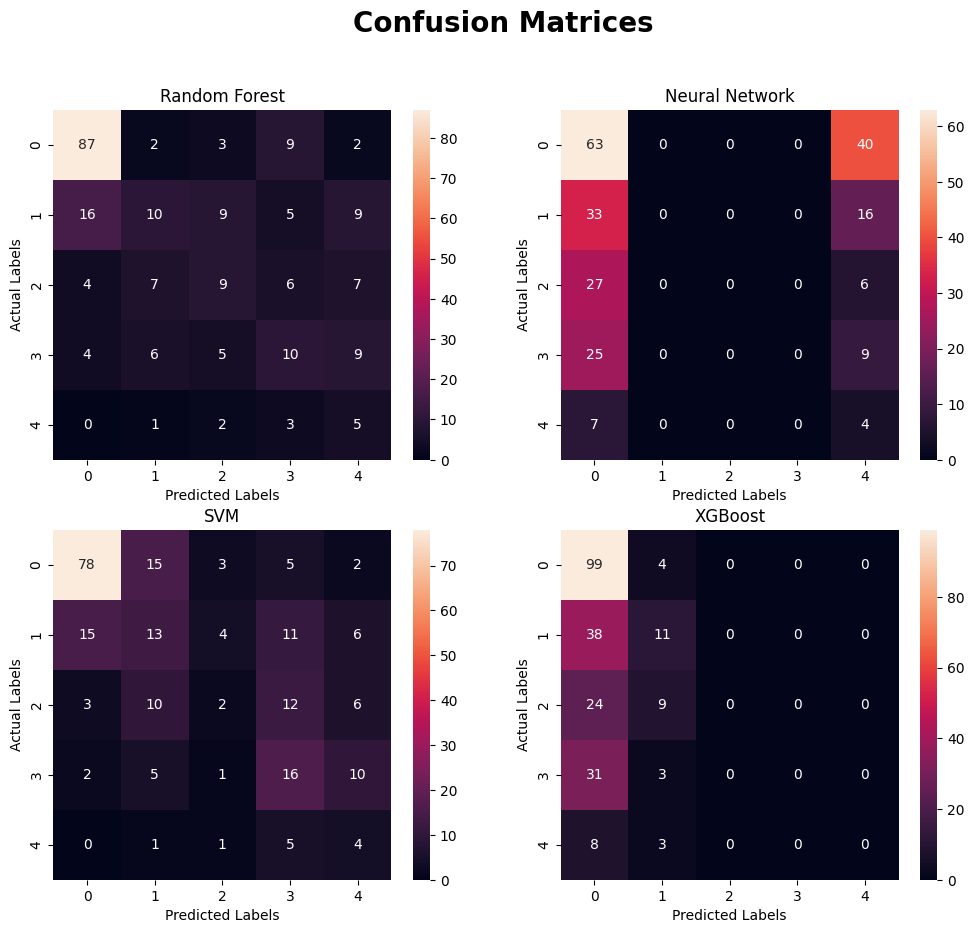

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(rf_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Random Forest')

plt.subplot(2, 2, 2)
sns.heatmap(nn_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Neural Network')

plt.subplot(2, 2, 3)
sns.heatmap(svm_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('SVM')

plt.subplot(2, 2, 4)
sns.heatmap(xgb_cm, annot=True, fmt='g')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('XGBoost')
plt.suptitle("Confusion Matrices",fontsize=20,fontweight='bold')
plt.show()